In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from tqdm.autonotebook import tqdm
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_24440/1003344669.py:9: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/Light_House_DBS/light_house_DBS_decision_making


In [2]:
STN_DATA_path_PD = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_PD.yaml')
STN_DATA_path_std_DBS = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_std_DBS.yaml')
STN_DATA_path_sector_DBS = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_sector_DBS.yaml')
DEL_LIM_ARR = [0.1, 0.2, 0.5, 1.0]
FILE_PATHS = [STN_DATA_path_PD, STN_DATA_path_std_DBS, STN_DATA_path_sector_DBS]
TYPE = ['PD', 'STD_DBS', 'SECTOR_DBS']
LAT_STRENGTH = 0.0275
VAR_ARR = [0.01, 0.04, 0.39] 

In [3]:
yaml_path = os.path.join(project_root, 'params', 'decision_making_task_params', 'restless_bandits', 'params.yaml')
params = load_yaml(yaml_path)

In [4]:
# ENV params
NUM_ARMS = params['NUM_ARMS']
MEAN_REWARD = np.array([40,40,60,80])
REW_STD = np.array([4,4,4,4])
SCALING_FACTOR = params['SCALING_FACTOR']

# Training params
TRIALS = params['TRIALS']
EPOCHS = 100 #params['EPOCHS']
BINS = params['NUM_BINS']
LR = params['LR']


LAMBDA_DECAY = 0.9836
THETA = 50
DIFFUSIVE_NOISE_MEAN = 0
DIFFUSIVE_NOISE_STD = 2.8


ARM_MONITOR = defaultdict(dict)
ARM_TRACKER = defaultdict(dict)
PROB_OPTIMAL_MONITOR = defaultdict(dict)
MEAN_PROB_MONITOR = defaultdict(dict)
REWARD_MONITOR = defaultdict(dict)

In [5]:
env = RestlessBanditsEnv(num_arms=NUM_ARMS, 
                         mean_reward=MEAN_REWARD/SCALING_FACTOR, 
                         std = REW_STD/SCALING_FACTOR,
                         lambda_decay = LAMBDA_DECAY, 
                         theta = THETA/SCALING_FACTOR, 
                         diffusive_noise_std = DIFFUSIVE_NOISE_STD/SCALING_FACTOR, 
                         diffusive_noise_mean = DIFFUSIVE_NOISE_MEAN/SCALING_FACTOR)


In [6]:
# Calculate average Prob of best arm picking every bin
def max_rew_arm(x:dict):
    rew_list = np.array([x[key][0] for key in list(x.keys())])
    return np.argmax(rew_list)

def process_epoch_optimal_arm(x:list):
    optimal_arm = [max_rew_arm(x[trail]) for trail in range(len(x)-1)]
    return optimal_arm

In [7]:
t = 0
for file_path in tqdm(FILE_PATHS):
    print(f'Running: {TYPE[t]}')
    args = load_yaml(file_path)
    args['lat_strength_stn'] = LAT_STRENGTH
    save_temp_path = os.path.join(project_root, 'temp', 'temp.yaml')
    save_yaml(args, save_temp_path)
    for del_lim in DEL_LIM_ARR:
        reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor, arm_tracker_full= train(env, 
                                                      trails = TRIALS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = BINS,
                                                      STN_data = save_temp_path, 
                                                      d1_amp=1,
                                                      d2_amp=0.00325,#0.003,#0.0035,
                                                      gpi_threshold=0.3,
                                                      max_gpi_iters=50,
                                                      del_lim=del_lim, train_IP = False, 
                                                      del_med = None, printing = False,
                                                      gpi_mean= 1, ep_0 = 0,
                                                      alpha_ep = 0.0,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0, 
                                                      track_arms = True)
        
    
        ARM_MONITOR[TYPE[t]][del_lim] = arm_chosen_monitor
        REWARD_MONITOR[TYPE[t]][del_lim] = reward_monitor
        # DP_MONITOR[TYPE[t]][del_lim] = dp_monitor
        # IP_MONITOR[TYPE[t]][del_lim] = ip_monitor
        ARM_TRACKER[TYPE[t]][del_lim] = arm_tracker_full


        OPTIMAL_CHOICE_ARRAY = np.array([process_epoch_optimal_arm(ARM_TRACKER[TYPE[t]][del_lim][epoch]) for epoch in range(len(ARM_TRACKER[TYPE[t]][del_lim]))])
        ACTUAL_CHOICE_ARRAY = np.array(ARM_MONITOR[TYPE[t]][del_lim])
        NUMBER_OF_MATCHES = (OPTIMAL_CHOICE_ARRAY == ACTUAL_CHOICE_ARRAY)*1
        PROB = np.mean(NUMBER_OF_MATCHES,axis = 1)
        mean_prob = np.mean(PROB)

        # OPTIMAL_CHOICE_MONITOR[TYPE[t]][del_lim] = OPTIMAL_CHOICE_ARRAY
        # ACTUAL_CHOICE_MONITOR[TYPE[t]][del_lim] = ACTUAL_CHOICE_ARRAY
        PROB_OPTIMAL_MONITOR[TYPE[t]][del_lim] = PROB
        MEAN_PROB_MONITOR[TYPE[t]][del_lim] = mean_prob
        print(f'del_lim = {del_lim} and type = {TYPE[t]}: mean prob of optimal arm = {mean_prob}')
    t +=1 


  0%|          | 0/3 [00:00<?, ?it/s]

Running: PD
Running STN-GPe system


  0%|          | 0/50000 [00:00<?, ?it/s]

StdDev of STN: 0.0756759709399454, Mean of STN: 1.0


  0%|          | 0/100 [00:00<?, ?it/s]

...

del_lim = 0.5 and type = SECTOR_DBS: mean prob of optimal arm = 0.5675333333333332
Running STN-GPe system


  0%|          | 0/50000 [00:00<?, ?it/s]

StdDev of STN: 0.3349999999997986, Mean of STN: 1.0


  0%|          | 0/100 [00:00<?, ?it/s]

del_lim = 1.0 and type = SECTOR_DBS: mean prob of optimal arm = 0.5761666666666666


In [8]:
DEL_LIM_ARR_FILTERED = DEL_LIM_ARR
Mean_Probs_PD = [MEAN_PROB_MONITOR[TYPE[0]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Mean_Probs_std_DBS = [MEAN_PROB_MONITOR[TYPE[1]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Mean_Probs_sector_DBS = [MEAN_PROB_MONITOR[TYPE[2]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]

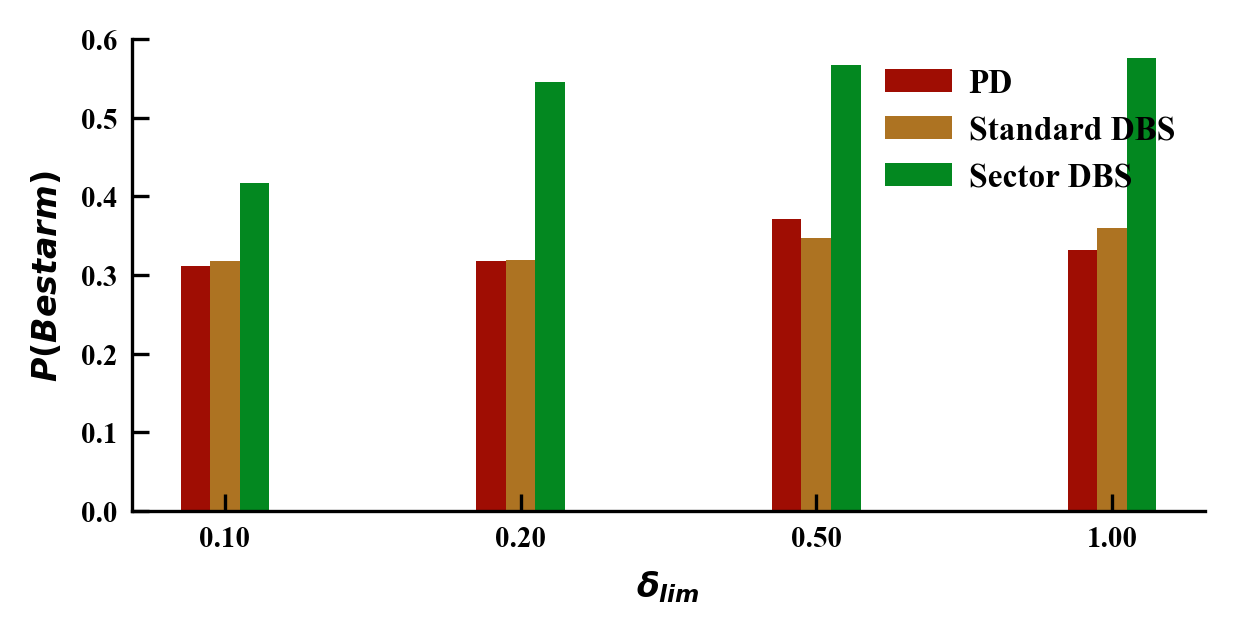

In [9]:
# plotting bar plot for each del lim on x axis and prob on y axis. Different colors for each var
bar_width = 0.1
x_values = np.arange(len(DEL_LIM_ARR_FILTERED))
alpha = 1

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ce",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}

plt.figure(figsize=(4,2))
plt.bar(x_values - bar_width, Mean_Probs_PD, width=bar_width, label="PD", alpha=alpha, color=colors['PD'], capsize=4)
plt.bar(x_values, Mean_Probs_std_DBS, width=bar_width, label="Standard DBS", alpha=alpha, color=colors['std_DBS'], capsize=4)
plt.bar(x_values + bar_width, Mean_Probs_sector_DBS, width=bar_width, label="Sector DBS", alpha=alpha, color = colors['sector_DBS'], capsize=4)
plt.legend()
plt.ylim(0,0.6)
plt.xticks(x_values, [f"{v:.2f}" for v in DEL_LIM_ARR], rotation=0)
plt.xlabel('$\delta_{lim}$')
plt.ylabel('$P(Best arm)$')
plt.show()

In [10]:
# # saving pickle with lat name
# data = {'DEL_LIM_ARR': DEL_LIM_ARR,
#         'TYPE': TYPE,
#         'ARM_MONITOR': ARM_MONITOR,
#         'LAT_STRENGTH': LAT_STRENGTH,
#         'ARM_TRACKER': ARM_TRACKER,
#         'MEAN_PROB_MONITOR': MEAN_PROB_MONITOR,
#         'PROB_OPTIMAL_MONITOR': PROB_OPTIMAL_MONITOR,
#         'REWARD_MONITOR': REWARD_MONITOR}
# file_name = 'restless_bandits_data_lat_' + str(LAT_STRENGTH).replace('.', '_') + '_2.pkl'
# file_path = os.path.join(project_root, 'simulations', 'decision_making_tasks', 'restless_bandits', file_name)

# with open(file_path, 'wb') as f:
#     pickle.dump(data, f)

In [11]:
# _1: d2_amp = 0.0035
# _2: d2_amp = 0.003
# _3: d2_amp = 0.003 
# _4: d2_amp = 0.0031
# _5: d2_amp = 0.003 => ran for 100 epochs
# _6: d2_amp = 0.003 => ran for 100 epochs

# _7: d2_amp = 0.00325 => ran for 100 epochs